In [ ]:
# ioモジュール(画像読み込み関連)のインポート
from skimage import io

# transformモジュール(画像操作関連)のインポート
from skimage import transform

In [ ]:
# 画像を読み込んで画像の中身を確認する
img = io.imread('/content/drive/Shareddrives/iOS/data/sat_image_2016_01/2016-01-01/2016-01-01-01-00.fv.png')
print(img)
print(type(img))

[[[187 187 187]
  [188 188 188]
  [188 188 188]
  ...
  [132 132 132]
  [131 131 131]
  [140 140 140]]

 [[187 187 187]
  [189 189 189]
  [187 187 187]
  ...
  [132 132 132]
  [139 139 139]
  [155 155 155]]

 [[188 188 188]
  [190 190 190]
  [188 188 188]
  ...
  [132 132 132]
  [135 135 135]
  [157 157 157]]

 ...

 [[ 61  61  61]
  [ 62  62  62]
  [ 62  62  62]
  ...
  [ 25  25  25]
  [ 25  25  25]
  [ 25  25  25]]

 [[ 60  60  60]
  [ 61  61  61]
  [ 62  62  62]
  ...
  [ 25  25  25]
  [ 25  25  25]
  [ 25  25  25]]

 [[ 60  60  60]
  [ 61  61  61]
  [ 61  61  61]
  ...
  [ 25  25  25]
  [ 25  25  25]
  [ 25  25  25]]]
<class 'numpy.ndarray'>


/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [3]:
# 画像の大きさを確認(高さ, 幅, チャンネル数)
print(img.shape)

(672, 512, 3)


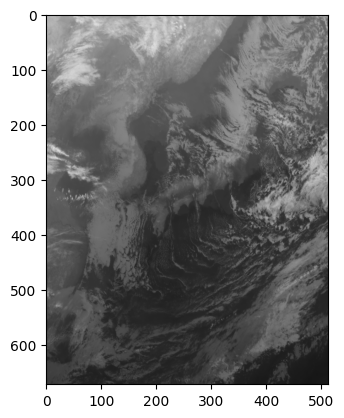

In [4]:
# pltのインポート
from matplotlib import pyplot as plt
# 画像の表示
plt.imshow(img)
plt.show()

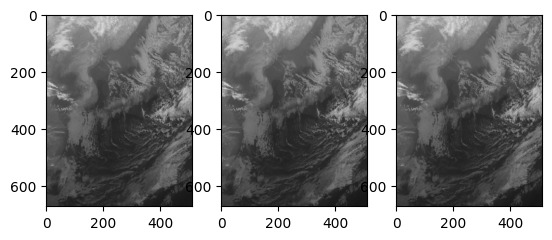

In [5]:
# 1行3列の1番目
plt.subplot(1,3,1)
plt.imshow(img)

# 1行3列の2番目
plt.subplot(1,3,2)
plt.imshow(img)

# 1行3列の3番目
plt.subplot(1,3,3)
plt.imshow(img)

plt.show()

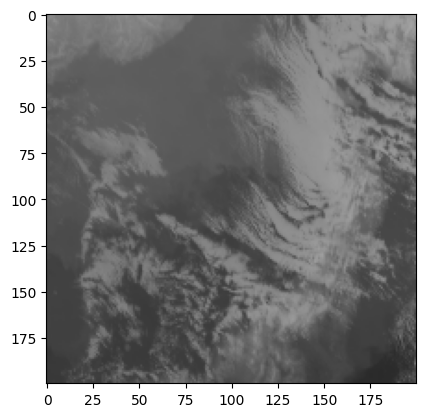

In [6]:
# 画像切り出し
img_trim = img[100:300,200:400]

# 切り出した画像表示
plt.imshow(img_trim)
plt.show()

In [7]:
# numpyのインポート
import numpy as np
# 配列の定義
tmp = np.array([1,2,3,4,5])
print(tmp)
# 反転した配列の表示
print(tmp[::-1])

[1 2 3 4 5]
[5 4 3 2 1]


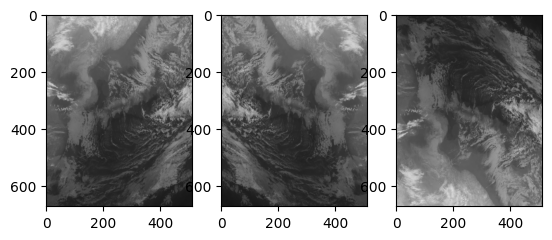

In [10]:
# 画像の水平反転（左右反転）
img_inv = img[:, ::-1]

# 画像の垂直反転（上下反転）
img_inv2 = img[::-1,:]

# 画像の複数表示
plt.subplot(1,3,1)
plt.imshow(img)
plt.subplot(1,3,2)
plt.imshow(img_inv)
plt.subplot(1,3,3)
plt.imshow(img_inv2)
plt.show()

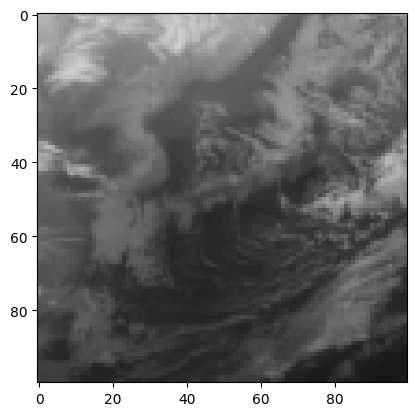

In [11]:
# 画像のリサイズ
img_resize = transform.resize(img,output_shape=(100,100))

# 画像の表示
plt.imshow(img_resize)
plt.show()

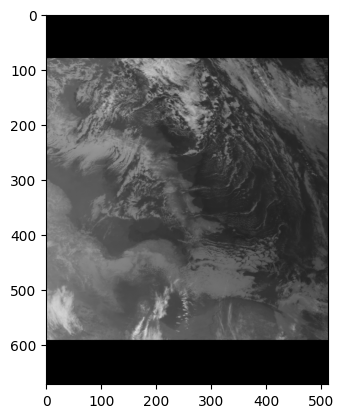

In [13]:
# 画像の回転(反時計回りに90度回転)
img_rotate = transform.rotate(img,angle=90)

# 画像の表示
plt.imshow(img_rotate)
plt.show()

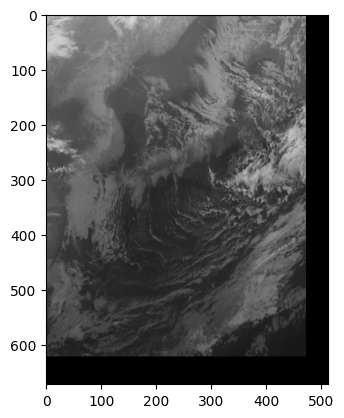

In [14]:
# 移動位置の定義(左方向に40ピクセル、上方向に50ピクセル)
rot = transform.AffineTransform(translation=(40,50))

# 画像の移動
img_affine = transform.warp(img,rot)

# 画像の表示
plt.imshow(img_affine)
plt.show()

In [15]:
# globのインポート
import glob

# ファイル名取り出し
files = glob.glob('/content/drive/Shareddrives/iOS/data/sat_image_2016_01/2016-01-01/*.png')

In [16]:
#複数画像読み込み
train_imgs = []
for fname in files:
    # 画像読み込み
    img = io.imread(fname)
    # train_imgsに今読み込んだ画像を格納
    train_imgs.append(img)
# train_imgsの型を出力
print(type(train_imgs))

# train_imgsをNumPy配列化し、その型と形状(総数、縦のサイズ、横のサイズ、チャネル数)を出力
train_imgs = np.array(train_imgs)
print(type(train_imgs) , train_imgs.shape)

/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in by

<class 'list'>
<class 'numpy.ndarray'> (23, 672, 512, 3)


/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


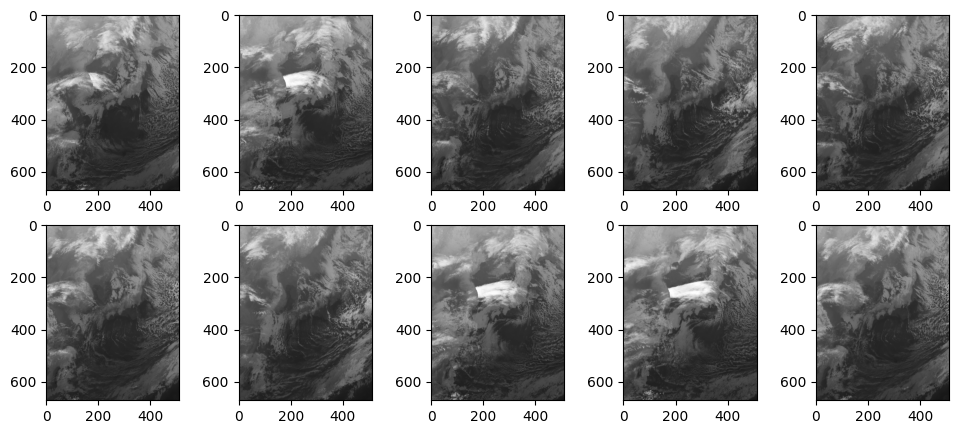

In [17]:
# 画像表示
plt.figure(figsize=(12,5))
for i in range(10):

    # 2行5列のi+1番目の画像を設定
    plt.subplot(2,5,i+1)

    # 画像の表示
    plt.imshow(train_imgs[i])

plt.show()

In [18]:
# train_imgsを正規化
train_imgs = train_imgs/255

In [19]:
"""
# ライブラリのインポート
import pandas as pd

# ファイル名からラベルを取得する(train_bird_1.jpg → bird)
labels=[]
for fname in files:
    labels.append(fname.split('_')[1])

# one-hot-encoding
labels_dummy = pd.get_dummies(labels)
print(labels_dummy)

# 画像のデータ分割（学習用と評価用）
X_tr, X_val = np.split(train_imgs,[8])

# ラベルのデータ分割（学習用と評価用）
y_tr, y_val = np.split(labels_dummy,[8])

print(X_tr.shape, X_val.shape)
print(y_tr.shape, y_val.shape)
"""

"\n# ライブラリのインポート\nimport pandas as pd\n\n# ファイル名からラベルを取得する(train_bird_1.jpg → bird) \nlabels=[]\nfor fname in files:\n    labels.append(fname.split('_')[1])\n\n# one-hot-encoding\nlabels_dummy = pd.get_dummies(labels)\nprint(labels_dummy)\n"

In [22]:
# KerasのSequentialのインポート
# Sequential：モデルの箱を準備する
from keras.models import Sequential

# KerasのDense , Activationのインポート
# Dense(X)：全結合層を意味し、Xはノード数を表す
# Activation('xxx')：活性化関数を意味し、xxxに活性化関数を記述する
from keras.layers import Dense
from keras.layers import Activation

In [23]:
# モデルの定義
model = Sequential()
model.add(Dense(10 , input_shape = (23,)))
model.add(Dense(10))
model.add(Dense(1))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [25]:
# ニューラルネットワークの定義
model = Sequential()
# 中間層①
model.add(Dense(150, input_shape=(101,)))
model.add(Activation('sigmoid'))
# 中間層②
model.add(Dense(200))
model.add(Activation('tanh'))
# 中間層③
model.add(Dense(100))
model.add(Activation('relu'))
# 出力層④
model.add(Dense(10))
model.add(Activation('softmax'))

In [26]:
# モデルの確認
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 150)            │        15,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 200)            │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,010 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,610 (260.20 KB)

 Trainable params: 66,610 (260.20 KB)

 Non-trainable params: 0 (0.00 B)